In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import pandas as pd
import numpy as np

from analysis_utils import load_results_as_dataframe, analyze_difficulty


In [4]:
file_path = 'instance_params.csv'
df = pd.read_csv(file_path)

help="""

    n (number of customers)

    Depot positioning
        1 = Random				
        2 = Centered				
        3 = Cornered				
                        
    Customer positioning
        1 = Random				
        2 = Clustered				
        3 = Random-clustered		
                        
    Demand distribution	
        1 = Unitary		
        2 = Small, large var		
        3 = Small, small var		
        4 = Large, large var		
        5 = Large, small var		
        6 = Large, depending on quadrant	
        7 = Few large, many small

    Average route size
        1 = Ultra short
        2 = Very short
        3 = Short
        4 = Medium
        5 = Long
        6 = Very long
        7 = Ultra long
        
    Output: instance file XL-nA-kB.vrp

    This script was used to generate the instances of the CVRPLIB Best Known Solution Challenge. For more details about the generation process read:
        Uchoa et al (2017). New benchmark instances for the Capacitated Vehicle Routing Problem. European Journal of Operational Research
        Queiroga, Eduardo, et al. (2022). 10,000 optimal CVRP solutions for testing machine learning based heuristics.
        """
display(df.head())

,Instance File Name,n (from file),k (Vehicles),n (raw script arg),Depot Positioning,Customer Positioning,Demand Distribution,Average Route Size,Seed
0,XLTEST-n1048-k139.vrp,1048,139,1047,2,3,3,2,423796
1,XLTEST-n1094-k9.vrp,1094,9,1093,1,2,4,7,730929
2,XLTEST-n1141-k75.vrp,1141,75,1140,3,1,5,4,610871
3,XLTEST-n1188-k72.vrp,1188,72,1187,3,1,7,5,602976
4,XLTEST-n1234-k252.vrp,1234,252,1233,1,3,2,1,725786


In [23]:
instance_dir = '../XLTEST'
instance_names = [i.split('.')[0] for i in os.listdir(instance_dir) if i.endswith('.vrp')]

In [24]:
algorithm_names = [
    'Mahdi_baseline',
    'AILSII_perturbation2_5d',
    'AILSII_deco_5d'
]

fitness_df, gap_df = load_results_as_dataframe(
    instance_names, 
    algorithm_names, 
    base_dir='../remote_results/test-5days',  # 你的数据根目录
    baseline='Mahdi_baseline'
)

--- 正在加载 100 个实例和 3 个算法的数据 ---
Fitness 数据加载完成。
基准: 算法 'Mahdi_baseline'


In [25]:
fitness_df.head()

,Mahdi_baseline,AILSII_perturbation2_5d,AILSII_deco_5d
XLTEST-n3561-k54,63466.0,63448.0,63493.0
XLTEST-n6884-k434,491686.0,491953.0,494181.0
XLTEST-n2261-k168,281326.0,281422.0,281533.0
XLTEST-n3804-k254,464971.0,465048.0,465107.0
XLTEST-n2587-k114,193842.0,194116.0,194011.0


In [26]:
gap_df.head()       # 其中gap是相对于BKS的百分比差距

,Mahdi_baseline,AILSII_perturbation2_5d,AILSII_deco_5d
XLTEST-n3561-k54,0.0,-0.028362,0.042542
XLTEST-n6884-k434,0.0,0.054303,0.507438
XLTEST-n2261-k168,0.0,0.034124,0.073580
XLTEST-n3804-k254,0.0,0.016560,0.029249
XLTEST-n2587-k114,0.0,0.141352,0.087184


In [27]:
analyze_difficulty(gap_df, top_k=3, methods_to_show=['AILSII_perturbation2_5d', 'AILSII_deco_5d'])


   深度难度分析 (Based on Gap %)

🔹 算法: [AILSII_perturbation2_5d]
  - 最小 Gap: -0.1860%
  - 平均 Gap: 0.0275%
  - 最大 Gap: 0.2170%
  - 达到/超越 BKS 数量: 26 (其中严格超越: 26)
  ✅ [Tier 1] 达到或超越 BKS 的实例 (共 27 个):
     XLTEST-n2681-k15     : -0.1860% 🌟 NEW BEST!
     XLTEST-n4844-k45     : -0.1569% 🌟 NEW BEST!
     XLTEST-n1701-k10     : -0.1146% 🌟 NEW BEST!
     XLTEST-n6305-k58     : -0.1095% 🌟 NEW BEST!
     XLTEST-n7037-k2302   : -0.0487% 🌟 NEW BEST!
     XLTEST-n1141-k75     : -0.0421% 🌟 NEW BEST!
     XLTEST-n1281-k42     : -0.0307% 🌟 NEW BEST!
     XLTEST-n3561-k54     : -0.0284% 🌟 NEW BEST!
     XLTEST-n5061-k951    : -0.0240% 🌟 NEW BEST!
     XLTEST-n5902-k126    : -0.0236% 🌟 NEW BEST!
     XLTEST-n2401-k16     : -0.0217% 🌟 NEW BEST!
     XLTEST-n1514-k125    : -0.0185% 🌟 NEW BEST!
     XLTEST-n3408-k627    : -0.0163% 🌟 NEW BEST!
     XLTEST-n1234-k252    : -0.0147% 🌟 NEW BEST!
     XLTEST-n2727-k175    : -0.0136% 🌟 NEW BEST!
     XLTEST-n2914-k852    : -0.0076% 🌟 NEW BEST!
     XLTEST-n3101-k685 

--- 开始绘制 Gap 分析 (基于 .sol 文件) ---
--- Gap 分析完成. 图像已保存至 ../figures/feature_analysis/gap_analysis_scatter_sol.png ---


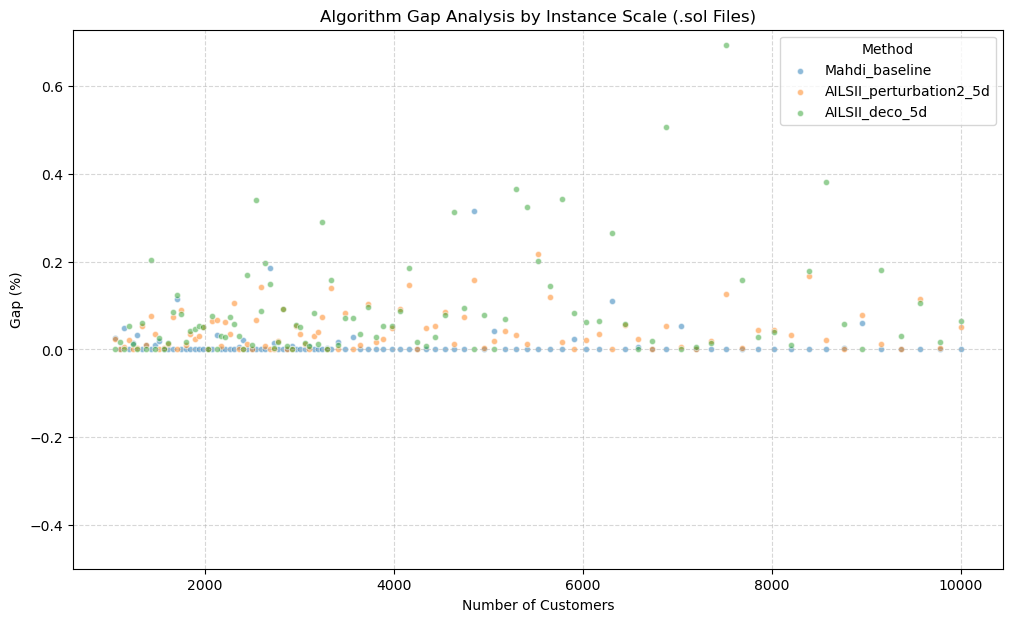

In [28]:
from plot_utils import plot_gap_scatter_from_sol

plot_gap_scatter_from_sol(instance_names, algorithm_names, base_dir='../remote_results/test-5days', output_dir='../figures/feature_analysis', point_alpha=0.5, point_size=20)

In [29]:
from plot_utils import get_average_gap_statistics

df_avg_gap = get_average_gap_statistics(instance_names, algorithm_names, base_dir='../remote_results/test-5days', baseline='Mahdi_baseline')
df_avg_gap

--- 开始计算平均 Gap (基于 .sol 文件) | Baseline模式: Mahdi_baseline ---

--- 平均 Gap 统计表 ---
                    Method  Average Gap (%)
2           Mahdi_baseline         0.000000
1  AILSII_perturbation2_5d         0.027542
0           AILSII_deco_5d         0.075074


,Method,Average Gap (%)
2,Mahdi_baseline,0.000000
1,AILSII_perturbation2_5d,0.027542
0,AILSII_deco_5d,0.075074


In [30]:
from plot_utils import get_rank_statistics

get_rank_statistics(instance_names, algorithm_names, base_dir='../remote_results/test-5days', output_csv='../figures/feature_analysis/rank_statistics.csv')

--- 开始统计算法排名情况 (基于 .sol 文件) ---

--- 排名统计表 (Rank Statistics) ---
                         Rank 1  Rank 2  Rank 3
Method                                         
AILSII_deco_5d               14      25      61
AILSII_perturbation2_5d      19      56      25
Mahdi_baseline               69      19      12
表格已保存至: ../figures/feature_analysis/rank_statistics.csv


,Rank 1,Rank 2,Rank 3
Method,,,
AILSII_deco_5d,14,25,61
AILSII_perturbation2_5d,19,56,25
Mahdi_baseline,69,19,12


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. 读取 Gap 文件并合并数据
# ==========================================

# 读取 gap 数据
# 假设该文件的第一列是 Instance Name，其余列是算法 Gap
# 如果你的实例名列名不是 'Instance File Name'，请在 merge 时指定 left_on/right_on
df_gaps_clean = gap_df.copy()
print("处理前 df_gaps 形状:", df_gaps_clean.shape)

df_gaps_clean.reset_index(inplace=True)
first_col_name = df_gaps_clean.columns[0]
df_gaps_clean.rename(columns={first_col_name: 'Instance File Name'}, inplace=True)

# 确保实例名两边都是字符串且去除空格，防止匹配失败
df['Instance File Name'] = df['Instance File Name'].astype(str).str.strip()
df['Instance File Name'] = df['Instance File Name'].str.replace('.vrp', '', regex=False)

df_merged = pd.merge(df, df_gaps_clean, on='Instance File Name', how='inner')

print("-" * 30)
if df_merged.empty:
    print("❌ 错误：合并后数据为空！")
    print("请检查下面两边的名字样本是否一致：")
    print("参数表 (df) 样本:", df['Instance File Name'].head(3).values)
    print("Gap表 (df_gaps) 样本:", df_gaps_clean['Instance File Name'].head(3).values)
else:
    print(f"🎉 完美合并成功！共 {len(df_merged)} 个实例。")
    print("包含的列:", df_merged.columns.tolist())
    
    # 展示前几行
    display(df_merged.head())
    
    # 将合并后的数据保存，供后续分析直接使用
    df_merged.to_csv('merged_analysis_data.csv', index=False)
    print("📁 已保存合并数据到 'merged_analysis_data.csv'")


处理前 df_gaps 形状: (100, 3)
------------------------------
🎉 完美合并成功！共 100 个实例。
包含的列: ['Instance File Name', 'n (from file)', 'k (Vehicles)', 'n (raw script arg)', 'Depot Positioning', 'Customer Positioning', 'Demand Distribution', 'Average Route Size', 'Seed', 'Mahdi_baseline', 'AILSII_perturbation2_5d', 'AILSII_deco_5d']


,Instance File Name,n (from file),k (Vehicles),n (raw script arg),Depot Positioning,Customer Positioning,Demand Distribution,Average Route Size,Seed,Mahdi_baseline,AILSII_perturbation2_5d,AILSII_deco_5d
0,XLTEST-n1048-k139,1048,139,1047,2,3,3,2,423796,0.0,-0.001611,-0.025777
1,XLTEST-n1094-k9,1094,9,1093,1,2,4,7,730929,0.0,0.000000,0.016632
2,XLTEST-n1141-k75,1141,75,1140,3,1,5,4,610871,0.0,-0.042126,-0.048253
3,XLTEST-n1188-k72,1188,72,1187,3,1,7,5,602976,0.0,0.021760,0.053191
4,XLTEST-n1234-k252,1234,252,1233,1,3,2,1,725786,0.0,-0.014733,-0.001842


📁 已保存合并数据到 'merged_analysis_data.csv'


In [42]:

# ==========================================
# 2. 定义分析函数
# ==========================================

def analyze_algorithm_performance(df_merged, algo_name):
    """
    输入算法名称（列名），输出该算法 Gap 与各个参数的相关性分析图表
    """
    if algo_name not in df_merged.columns:
        print(f"❌ 错误：在数据中找不到算法列 '{algo_name}'")
        print(f"可用的算法列: {list(df_gaps_clean.columns[2])}")
        return

    print(f"📊 正在分析算法: 【{algo_name}】 ...")
    
    # ---------------------------
    # A. 数据准备 (类型转换)
    # ---------------------------
    # 确保参数列是数值型，以便绘图和计算
    cols_to_convert = ['n (from file)', 'k (Vehicles)', 'Depot Positioning', 
                       'Customer Positioning', 'Demand Distribution', 'Average Route Size']
    
    analysis_df = df_merged.copy()
    for col in cols_to_convert:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

    # ---------------------------
    # B. 计算数值相关性 (Spearman)
    # ---------------------------
    # 使用 Spearman 是因为它能捕捉非线性关系，且对序数数据（如 Route Size 1-7）更鲁棒
    corr_cols = cols_to_convert + [algo_name]
    correlation = analysis_df[corr_cols].corr(method='spearman')[algo_name].drop(algo_name)
    
    # 画相关性条形图
    plt.figure(figsize=(10, 4))
    colors = ['red' if x > 0 else 'green' for x in correlation.values]
    correlation.sort_values().plot(kind='barh', color=colors, alpha=0.7)
    plt.title(f'Feature Correlation with Gap ({algo_name}) \n (Spearman, Positive=Larger Gap/Worse)', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    
    print("💡 解读：红色条越长，表示该参数越大，Gap 越大（变差）；绿色条越长，表示该参数越大，Gap 越小（变好）。")

    # ---------------------------
    # C. 详细可视化 (分类 vs 连续)
    # ---------------------------
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Detailed Analysis for {algo_name}', fontsize=16)
    
    # 1. 规模影响 (n) - 散点图
    sns.scatterplot(data=analysis_df, x='n (from file)', y=algo_name, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].set_title('Impact of Customer Count (n)')
    axes[0, 0].set_ylabel('Gap')
    
    # 2. 车辆数影响 (k) - 散点图
    sns.scatterplot(data=analysis_df, x='k (Vehicles)', y=algo_name, ax=axes[0, 1], alpha=0.5)
    axes[0, 1].set_title('Impact of Vehicles (k)')
    
    # 3. 路径长度 (Route Size) - 箱线图 (因为是 1-7 的序数)
    sns.boxplot(data=analysis_df, x='Average Route Size', y=algo_name, ax=axes[0, 2], palette="Blues")
    axes[0, 2].set_title('Impact of Route Size (1=Short, 7=Long)')
    
    # 4. 仓库位置 (Depot) - 箱线图 (类别变量)
    sns.boxplot(data=analysis_df, x='Depot Positioning', y=algo_name, ax=axes[1, 0], palette="Set2")
    axes[1, 0].set_title('Depot Pos (1=Rand, 2=Center, 3=Corner)')
    
    # 5. 客户分布 (Customer) - 箱线图 (类别变量)
    sns.boxplot(data=analysis_df, x='Customer Positioning', y=algo_name, ax=axes[1, 1], palette="Set2")
    axes[1, 1].set_title('Cust Pos (1=Rand, 2=Clust, 3=Rand-Clust)')
    
    # 6. 需求分布 (Demand) - 箱线图
    sns.boxplot(data=analysis_df, x='Demand Distribution', y=algo_name, ax=axes[1, 2], palette="Set3")
    axes[1, 2].set_title('Demand Dist (Types 1-7)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



📊 正在分析算法: 【AILSII_perturbation2_5d】 ...


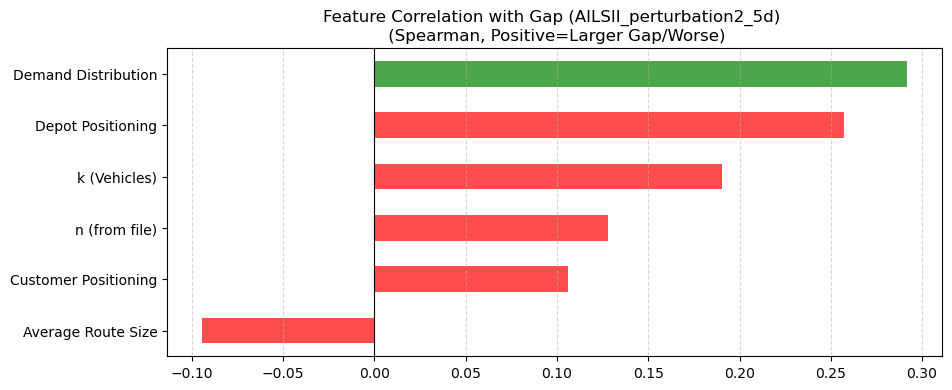

💡 解读：红色条越长，表示该参数越大，Gap 越大（变差）；绿色条越长，表示该参数越大，Gap 越小（变好）。


/tmp/ipykernel_1986992/1159750101.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Average Route Size', y=algo_name, ax=axes[0, 2], palette="Blues")
/tmp/ipykernel_1986992/1159750101.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Depot Positioning', y=algo_name, ax=axes[1, 0], palette="Set2")
/tmp/ipykernel_1986992/1159750101.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Customer Positioning', y=algo_name, ax=axes[1, 1], palette="Set2")
/tmp/ipykernel_1986992/115

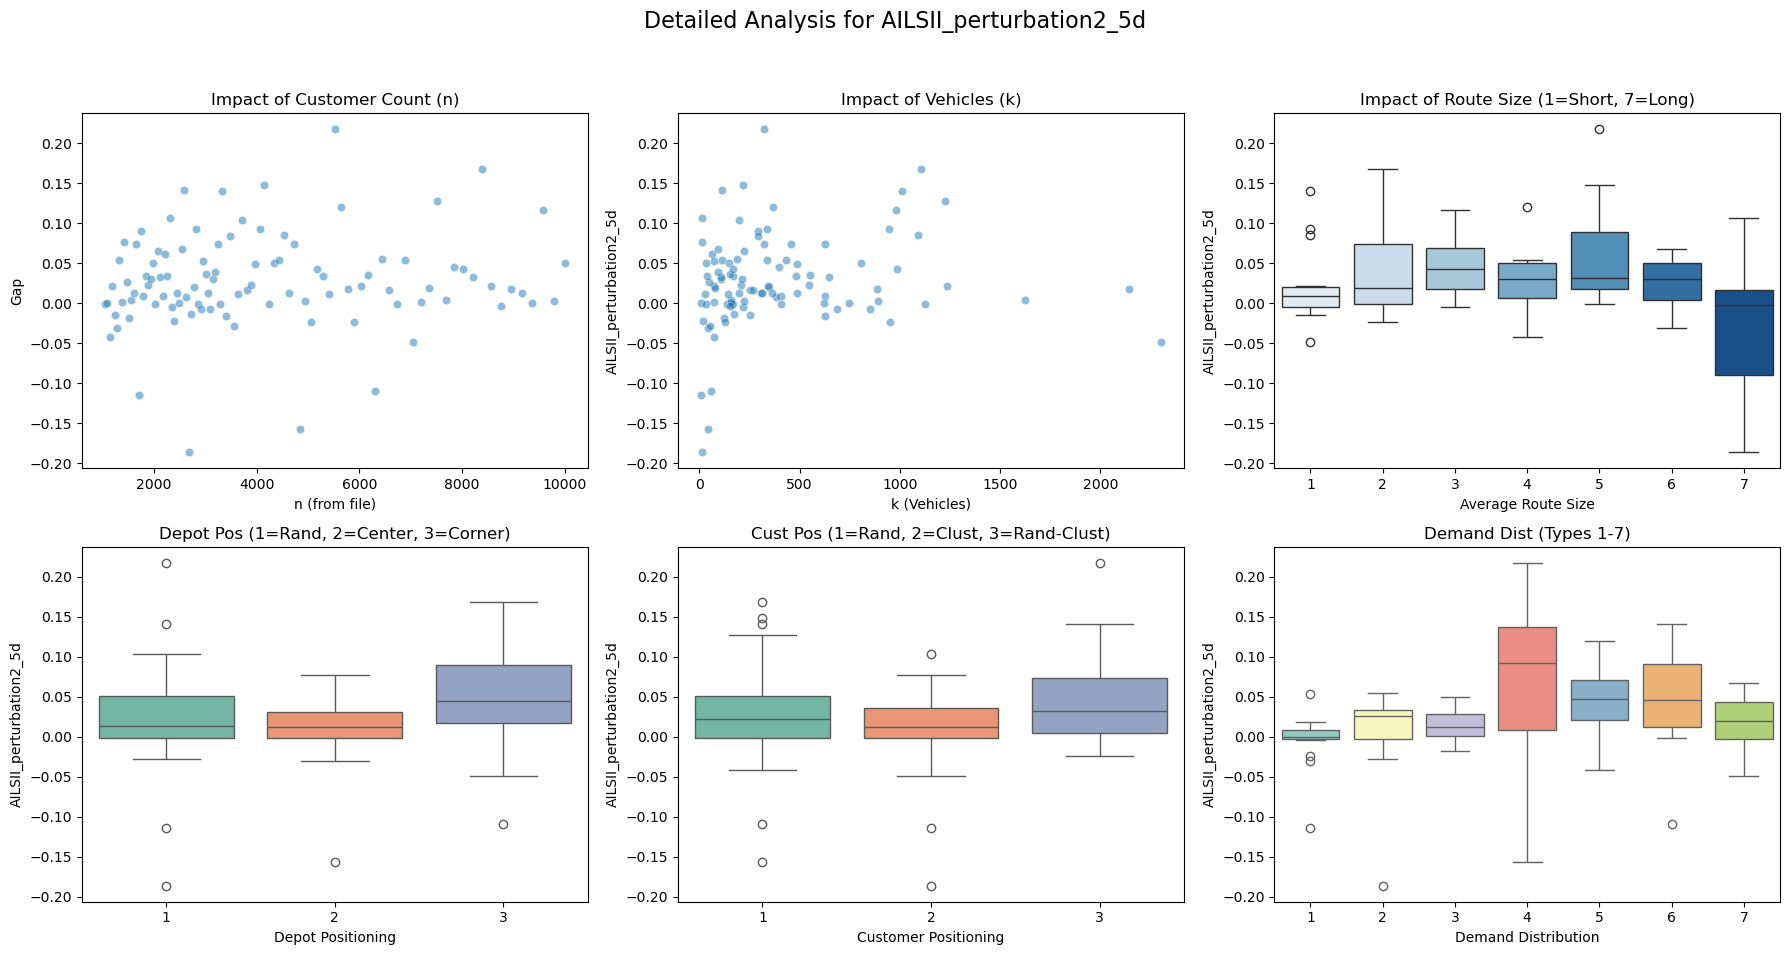

In [44]:
 analyze_algorithm_performance(df_merged, 'AILSII_perturbation2_5d')

📊 正在分析算法: 【AILSII_deco_5d】 ...


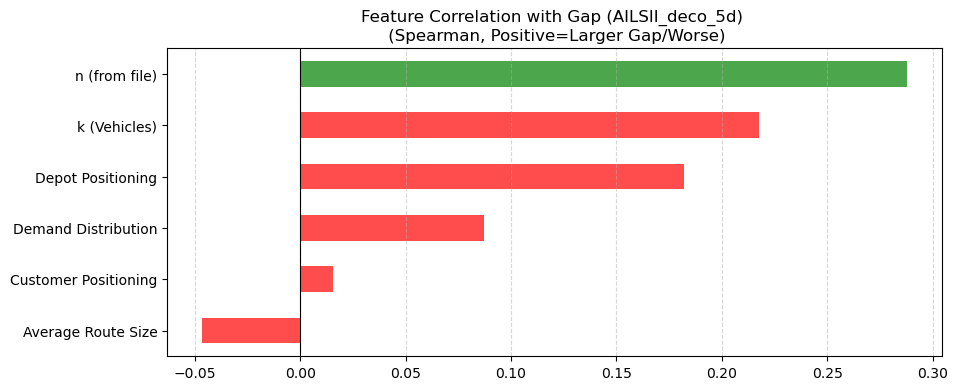

💡 解读：红色条越长，表示该参数越大，Gap 越大（变差）；绿色条越长，表示该参数越大，Gap 越小（变好）。


/tmp/ipykernel_1986992/1159750101.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Average Route Size', y=algo_name, ax=axes[0, 2], palette="Blues")
/tmp/ipykernel_1986992/1159750101.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Depot Positioning', y=algo_name, ax=axes[1, 0], palette="Set2")
/tmp/ipykernel_1986992/1159750101.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Customer Positioning', y=algo_name, ax=axes[1, 1], palette="Set2")
/tmp/ipykernel_1986992/115

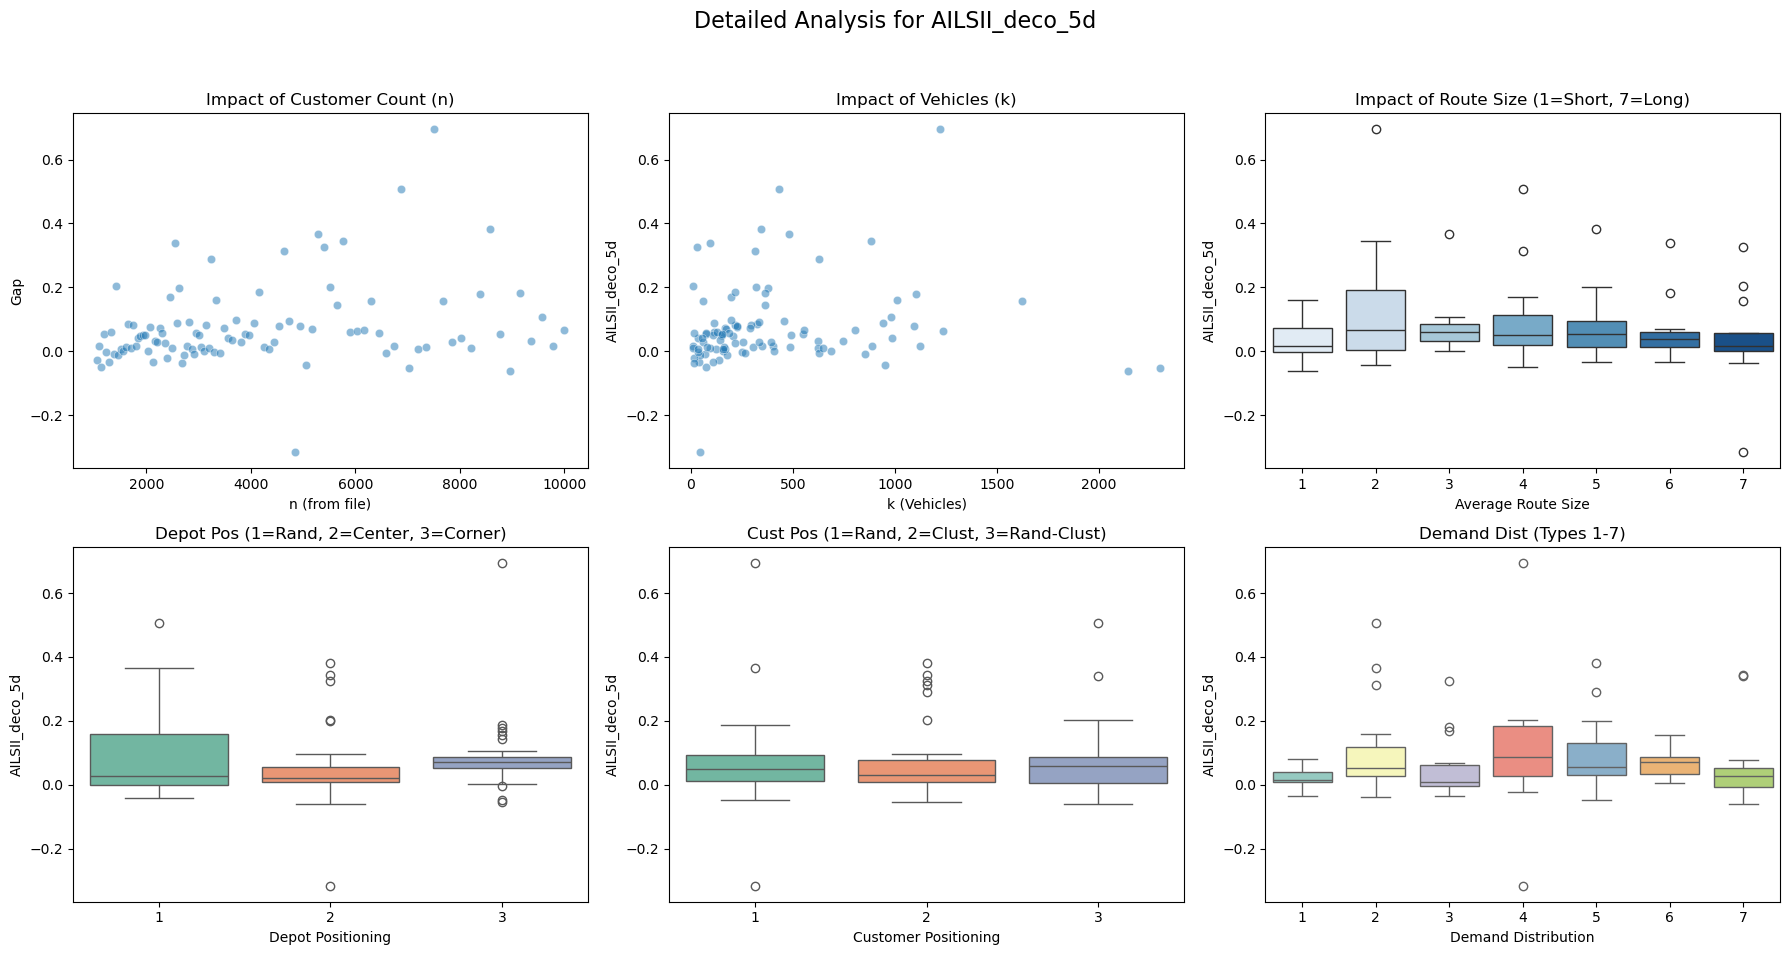

In [46]:
analyze_algorithm_performance(df_merged, 'AILSII_deco_5d')